In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

이 코드는 경사하강법을 통해서 직선이 데이터를 점점 잘 설명해가도록 바뀌는 과정이다.  
학습이 되면 -> w,b이 조금씩 수정되면서, 손실값은 점점 줄어든다.

epoch=0, loss=105.7228, w=0.2150, b=0.1995
epoch=200, loss=1.1733, w=4.6687, b=5.4308
epoch=400, loss=1.0422, w=4.3365, b=5.8074
epoch=600, loss=1.0062, w=4.1616, b=6.0045
epoch=800, loss=0.9962, w=4.0698, b=6.1079
최종 w: 4.021813642697164
최종 b: 6.162031224717461


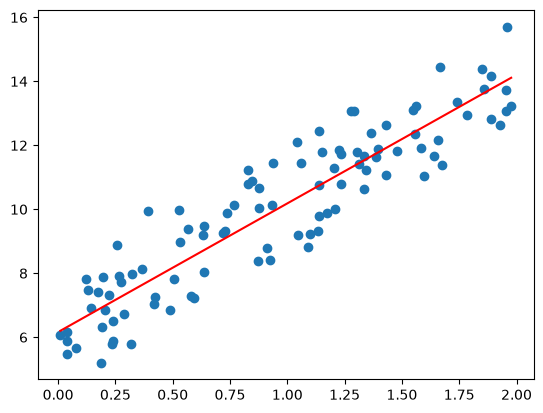

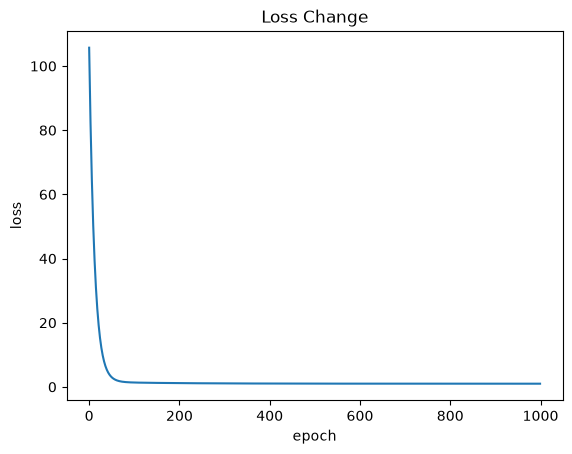

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)

# 2. 초기값 설정
w = 0                   # 기울기
b = 0                   # 절편
learning_rate = 0.01    # 학습률
epochs = 1000           # 반복 횟수
n = len(X)              # 데이터 갯수
    
loss_history = []       

# 3. 경사하강법 반복
for epoch in range(epochs):
    # 예측값
    y_pred = w * X + b  # 예측값 계산

    # 오차
    error = y_pred - y  # 예측값과 손실값의 차이 계산

    # 손실값(MSE)
    loss = np.mean(error ** 2)  # MSE 손실값 계산  (음수때문 제곱)
    loss_history.append(loss)   # 손실값 저장

    # 기울기 계산
    w_grad = (2 / n) * np.sum(X * error)    # w에 대한 기울기 계산  
    b_grad = (2 / n) * np.sum(error)        # b에 대한 기울기 계산

    # 파라미터 업데이트
    w = w - learning_rate * w_grad
    b = b - learning_rate * b_grad

    # 중간 결과 확인
    if epoch % 200 == 0:
        print(f"epoch={epoch}, loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

print("최종 w:", w)
print("최종 b:", b)

# 4. 학습된 직선 시각화
X_sorted = np.sort(X, axis=0)       # x값 정렬
y_pred_sorted = w * X_sorted + b    # 정렬된 x를 기준으로 예측값

plt.scatter(X, y)
plt.plot(X_sorted, y_pred_sorted, color="red")   # 학습된 회귀 직선
plt.show()

# 5. 손실값 변화 시각화
plt.plot(loss_history)  # 손실값 변화 그래프
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Change")
plt.show()

- # 선형 회귀 모델

기울기(coefficient): 2.0
절편(intercept): -0.20000000000000018
MSE: 0.15999999999999992
R^2 Score: 0.9803921568627451


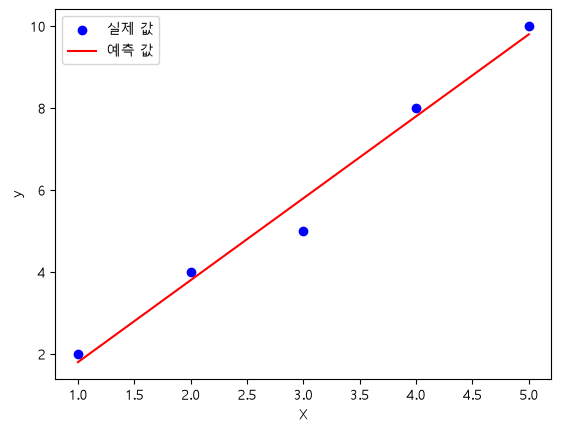

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 생성
X = np.array([[1], [2], [3], [4], [5]]) # 입력값 : 2차원
y = np.array([2, 4, 5, 8, 10])          # 출력값 : 1차원

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)             # 모델 합습(w,b 찾아냄)

# 예측 값 계산
y_pred = model.predict(X)   # 예측값 계산

# 평가 지표 계산
mse = mean_squared_error(y, y_pred)     # MSE 계산
r2 = r2_score(y, y_pred)                # R2 걀정계수

print(f'기울기(coefficient): {model.coef_[0]}') # 학습된 기울기 w 
print(f'절편(intercept): {model.intercept_}')   # 학습된 절편 b
print(f'MSE: {mse}')                            # 평균제곱오차(MSE)
print(f'R^2 Score: {r2}')                       # R2

# 결과 시각화
plt.scatter(X, y, color='blue', label='실제 값')        # 실제 데이터 산점도
plt.plot(X, y_pred, color='red', label='예측 값')       # 예측 데이터 회귀선
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

- # 다중 선형 회귀

회귀 계수(coefficient): [5.36082474 0.11237113]
절편(intercept): 259.4329896907218
MSE: 3.0927835051547214


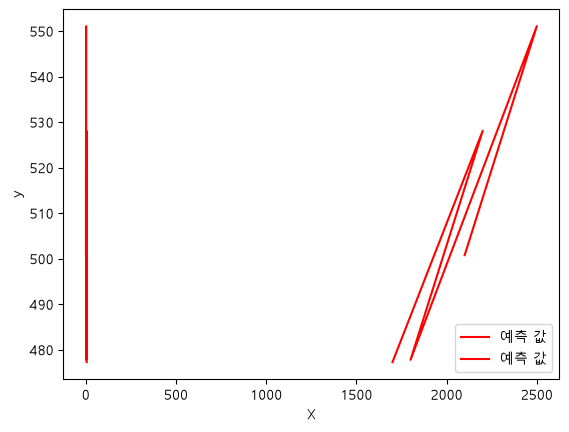

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 데이터 생성
X = np.array([[1, 2100], [2, 2500], [3, 1800], [4, 2200], [5, 1700]])   # 입력데이터 (방갯수, 면적)
y = np.array([500, 550, 480, 530, 475])

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 예측 값 계산
y_pred = model.predict(X)

# 평가 지표 계산
mse = mean_squared_error(y, y_pred)

print(f'회귀 계수(coefficient): {model.coef_}')
print(f'절편(intercept): {model.intercept_}')
print(f'MSE: {mse}')

# 결과 시각화
plt.plot(X, y_pred, color='red', label='예측 값')       # 예측 데이터 회귀선
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

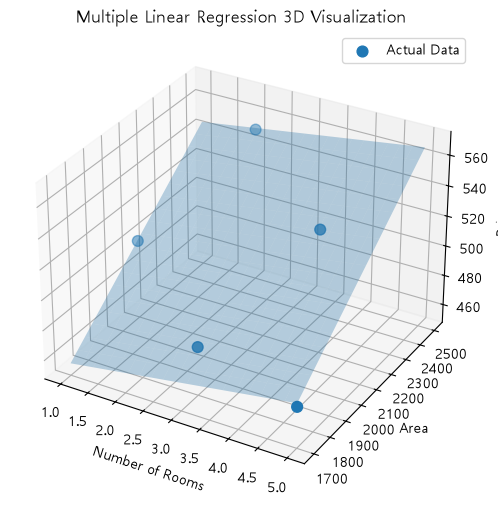

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D 그래프 생성
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# 실제 데이터 산점도
# X[:, 0] : 방 개수
# X[:, 1] : 면적
# y       : 실제 집 가격
ax.scatter(X[:, 0], X[:, 1], y, label="Actual Data", s=60)

# 회귀 평면을 그리기 위한 격자 데이터 생성
room_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
area_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)

room_grid, area_grid = np.meshgrid(room_range, area_range)

# 격자 데이터를 모델 입력 형태로 변환
grid_data = np.c_[room_grid.ravel(), area_grid.ravel()]

# 회귀 모델을 이용해 격자 위치의 예측 가격 계산
price_pred_grid = model.predict(grid_data)

# 예측 결과를 회귀 평면 형태로 변환
price_pred_grid = price_pred_grid.reshape(room_grid.shape)

# 회귀 평면 시각화
ax.plot_surface(room_grid, area_grid, price_pred_grid, alpha=0.3)

# 축 라벨 설정
ax.set_xlabel("Number of Rooms")
ax.set_ylabel("Area")
ax.set_zlabel("Price")

# 그래프 제목
ax.set_title("Multiple Linear Regression 3D Visualization")

# 범례 표시
ax.legend()

# 그래프 출력
plt.show()

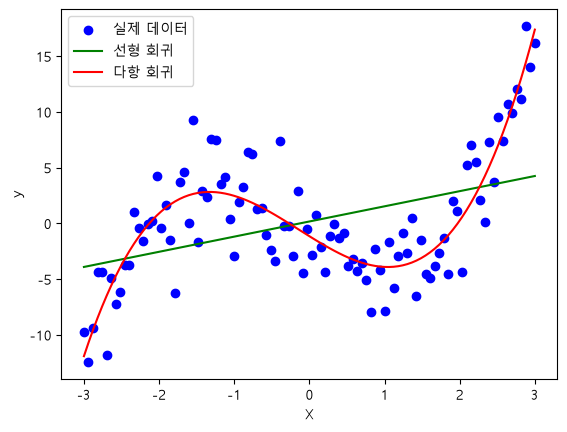

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 데이터 생성
np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1, 1)  #-3~3 까지 2차원
y = X**3 - 4 * X + np.random.randn(100, 1) * 3 # 3차 함수 + 오차

# 1. 일반 선형 회귀
linear_model = LinearRegression()
linear_model.fit(X, y)              # 학습
y_linear_pred = linear_model.predict(X) # 예측값

# 2. 다항 특성 변환
poly_features = PolynomialFeatures(degree=3, include_bias=False)    # 3차 특성
X_poly = poly_features.fit_transform(X)     # X -> X^2,X^3 등 변환

# 3. 다항 회귀 모델 학습
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# 4. 결과 시각화
plt.scatter(X, y, color="blue", label="실제 데이터")
plt.plot(X, y_linear_pred, color="green", label="선형 회귀")
plt.plot(X, y_poly_pred, color="red", label="다항 회귀")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

# 1. 데이터 생성
X, y = make_regression(
    n_samples=500,
    n_features=1,
    noise=20,
    random_state=42
)
print(X)
print(y)


[[-0.80829829]
 [ 0.09699596]
 [ 0.47323762]
 [-1.47852199]
 [-0.3853136 ]
 [-0.49300093]
 [ 2.18980293]
 [ 2.1221562 ]
 [ 0.35778736]
 [ 0.0976761 ]
 [-0.79252074]
 [ 0.09176078]
 [-1.23086432]
 [-0.34271452]
 [-0.60021688]
 [ 1.13556564]
 [-0.60170661]
 [ 0.06751848]
 [-0.14237949]
 [-0.60063869]
 [ 1.76545424]
 [-0.56228753]
 [ 0.63391902]
 [ 0.21397991]
 [ 0.31125015]
 [ 0.1990597 ]
 [-0.01224677]
 [ 0.95042384]
 [-1.06762043]
 [-0.80227727]
 [ 0.62411982]
 [-0.29169375]
 [-0.47917424]
 [-1.01283112]
 [-1.43586215]
 [ 1.03246526]
 [ 1.89679298]
 [-0.66178646]
 [ 1.17929718]
 [ 0.11567463]
 [-0.2176812 ]
 [ 0.29307247]
 [-1.95967012]
 [-0.30921238]
 [-0.19236096]
 [ 2.14394409]
 [ 0.67959775]
 [ 1.08305124]
 [ 0.62834551]
 [ 1.62861555]
 [ 0.0125924 ]
 [ 0.24196227]
 [-0.96492346]
 [-0.77300978]
 [-0.44651495]
 [-0.23413696]
 [-0.18565898]
 [-0.95554044]
 [ 0.61037027]
 [ 1.27767682]
 [ 0.12029563]
 [-1.41537074]
 [-0.25256815]
 [ 1.23781631]
 [ 0.51504769]
 [-0.14705738]
 [-3.24126

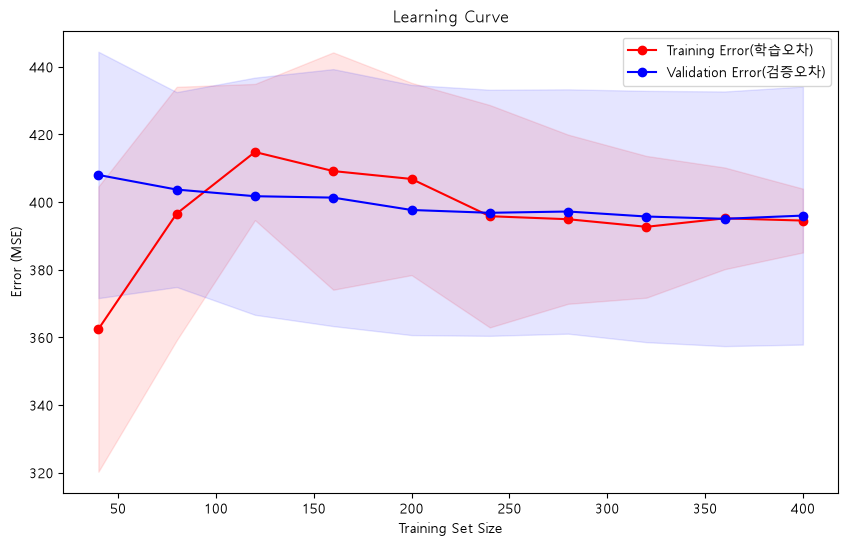

In [20]:

# 2. 학습 곡선 계산
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),   # 사용할 모델
    X,                    # 입력 데이터
    y,                    # 정답 데이터
    cv=5,                 # 교차검증
    scoring="neg_mean_squared_error",   # MES
    train_sizes=np.linspace(0.1, 1.0, 10),  # 학습데이터 비율(0.1 ~1.0 까지 10등분)_
    shuffle=True,                       # 데이터 섞기
    random_state=42
)

# 3. 평균과 표준편차 계산
# neg_mean_squared_error는 음수로 반환되므로 -를 붙여 양수 MSE로 변환
train_mean = -train_scores.mean(axis=1)     # 학습 MES 평균
train_std = train_scores.std(axis=1)        # 학습 MES 표준편차

val_mean = -val_scores.mean(axis=1)         # 검증 MES 평균
val_std = val_scores.std(axis=1)            # 검증 MES 표준편차

# 4. 학습 곡선 시각화
plt.figure(figsize=(10, 6))

# 학습 오차
plt.plot(
    train_sizes,        # X축 : 학습 데이터 크기
    train_mean,         # y축 : 학습 MES 평균
    "o-",               # 점,선 그래프  
    label="Training Error(학습오차)",
    color="red"
)
# 검증 오차
plt.plot(
    train_sizes,    # X축 : 학습 데이터 크기
    val_mean,       # y축 : 검증 오차 평균
    "o-",           # 점,선 그래프  
    label="Validation Error(검증오차)",
    color="blue"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,     # 학습 오차 하한
    train_mean + train_std,     # 학습 오차 상한
    alpha=0.1,
    color="red"
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,         # 검증 오차 하한
    val_mean + val_std,         # 검증 오차 상한
    alpha=0.1,
    color="blue"
)

plt.xlabel("Training Set Size")
plt.ylabel("Error (MSE)")
plt.title("Learning Curve")
plt.legend()
plt.show()